# 第三章 &nbsp; &nbsp; 神经网络  
- 神经网络的一个重要性质就是它可以自动地从数据中学习到合适的权重参数。  
- 神经网络由输入层，中间层（隐藏层），输出层构成。  
- 一般而言，朴素感知机是指单层网络，指的是激活函数使用了阶跃函数的模型。多层感知机是指神经网络，即使用sigmoid函数等平滑的激活函数的多层网络。

## 激活函数 
激活函数以阈值为界，一旦输入超过阈值，就切换输出。这样的函数称为“阶跃函数”。因此，可以说感知机中使用了阶跃函数作为激活函数。也就是说，在激活函数的众多候选函数中，感知机使用了阶跃函数。那么，如果感知机使用其他函数作为激活函数的话会怎么样呢？实际上，如果将激活函数从阶跃函数换成其他函数，就可以进入神经网络的世界了。

### sigmoid函数 
神经网络中经常使用的一个激活函数就是式 (3.6) 表示的 sigmoid 函数（sigmoid function）。

$$
h(x) = \frac{1}{1 + \exp(-x)} \tag{3.6}
$$

式 (3.6) 中的 $\exp(-x)$ 表示 $\mathrm{e}^{-x}$ 的意思。$\mathrm{e}$ 是纳皮尔常数 $2.7182\cdots$。式 (3.6) 表示的 sigmoid 函数看上去有些复杂，但它也仅仅是个函数而已。而函数就是给定某个输入后，会返回某个输出的转换器。比如，向 sigmoid 函数输入 $1.0$ 或 $2.0$ 后，就会有某个值被输出，类似 $h(1.0) = 0.731\cdots$、$h(2.0) = 0.880\cdots$ 这样。

## 阶跃函数的实现 
这里我们试着用Python画出阶跃函数的图（从视觉上确认函数的形状对理解函数而言很重要）。阶跃函数如式（3.3）所示，当输入超过0时，输出1，否则输出0。可以像下面这样简单地实现阶跃函数。

In [1]:
#阶跃函数的实现
def step_function_preview(x):
    if x > 0:
        return 1
    else:
        return 0

#numpy数组的实现
import numpy as np
def step_function(x):
    y = x > 0
    return y.astype(int)#将布尔型转换为int型,即True转换为1,False转换为0,astype()函数用于转换数组的数据类型

def step_function_pre(x):
    return np.where(x > 0,1,0)#numpy的where函数,第一个参数是条件,第二个参数是条件为真时的返回值,第三个参数是条件为假时的返回值
#上述方法比转化为布尔值更加简单方便快捷

x=np.array([-1.0,1.0,2.0])
print(x)
print()
y=x>0#numpy数组的不等号运算,返回一个布尔型数组
print(y)
print()
y=y.astype(int)
print(y)
print()
z=step_function_pre(x)
print(z)

[-1.  1.  2.]

[False  True  True]

[0 1 1]

[0 1 1]


## 阶梯函数的图形表示
下面我们就用图来表示上面定义的阶跃函数，为此需要使用matplotlib库。

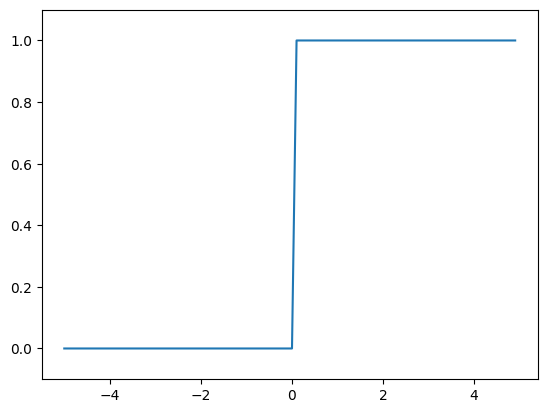

In [2]:
#阶梯函数的图形表示1
import numpy as np
import matplotlib.pylab as plt

def step_function(x):
    return np.array(x > 0, dtype=int)

x = np.arange(-5.0, 5.0, 0.1)#生成-5.0到5.0的数组,步长为0.1
y = step_function(x)
plt.plot(x, y)
plt.ylim(-0.1, 1.1)#设置y轴的范围
plt.show()

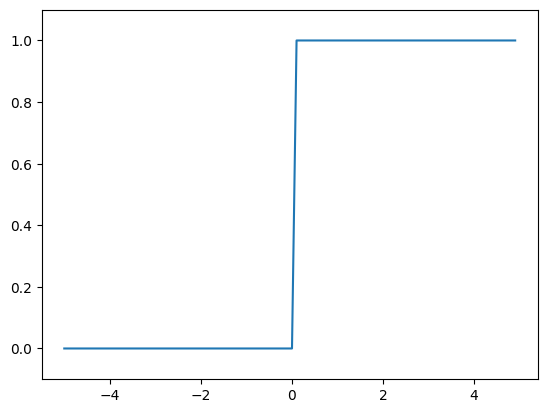

In [3]:
#阶梯函数的图像表示2,使用numpy的where函数,更加简洁
import numpy as np
import matplotlib.pylab as plt

def step_function(x):
    return np.where(x > 0, 1, 0)

x = np.arange(-5.0, 5.0, 0.1)
y = step_function(x)
plt.plot(x, y)
plt.ylim(-0.1, 1.1)
plt.show()

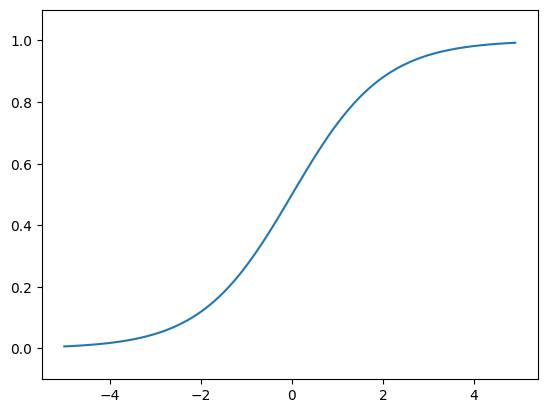

In [4]:
#sigmoid函数的实现
import numpy as np
import matplotlib.pylab as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.arange(-5.0, 5.0, 0.1)
y = sigmoid(x)
plt.plot(x, y)
plt.ylim(-0.1, 1.1)
plt.show()

## sigmoid函数和阶跃函数的比较  
- sigmoid函数是一条平滑的曲线，输出随着输入发生连续性的变化，而阶跃函数以0为界，输出发生急剧的变化。sigmoid函数的平滑性对神经网络的学习具有重大的意义。  
- 相较于阶跃函数只能返回0或1，sigmoid函数可以返回0到1上不同的实数。也就是说，感知机中神经元之间流动的是0或1的二元信号，而神经网络中流动的是连续的实数值信号。  
- 阶跃函数和sigmoid函数有共同点，即两者都是非线性函数。而神经网络的激活函数必须使用非线性函数。若是使用线性函数的话，加深网络层数就没有意义了。

## ReLU函数的实现
到目前为止，我们介绍了作为激活函数的阶跃函数和sigmoid函数。在神经网络发展的历史上，sigmoid函数很早就开始被使用了，而最近则主要使用**ReLU**（Rectified Linear Unit）函数。

ReLU函数在输入大于0时，直接输出该值；在输入小于等于0时，输出0。

ReLU函数可以表示为下面的式 (3.7)。

$$
h(x) =
\begin{cases}
x & (x > 0) \\
0 & (x \leqslant 0)
\end{cases}
\tag{3.7}
$$

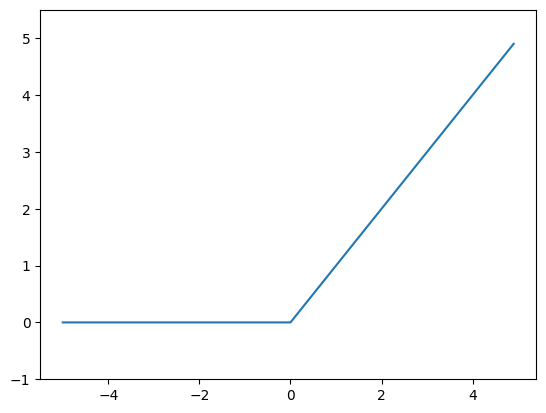

In [5]:
#ReLU函数的实现
import numpy as np
import matplotlib.pylab as plt

def relu(x):
    return np.maximum(0, x)

x = np.arange(-5.0, 5.0, 0.1)
y = relu(x)
plt.plot(x, y)
plt.ylim(-1.0, 5.5)
plt.show()

## 多维数组的运算
简单地讲，多维数组就是“数字的集合”，数字排成一列的集合、排成长方形的集合、排成三维状或者（更加一般化的）N维状的集合都称为多维数组。下面我们就用NumPy来生成多维数组，先从前面介绍过的一维数组开始。

In [6]:
#多维数组的运算
import numpy as np
A = np.array([1, 2, 3, 4])
print(A)
print()
print(np.ndim(A))#维度
print()
print(A.shape)#形状，返回一个元组，元组的元素是各个维度的长度,输出(数组个数,一个数组的元素个数)
print()
print(A.shape[0])#元素个数，即第一维的长度
print()
#一维数组是一个向量，多维数组是一个矩阵，多维数组的元素是向量
B=np.array([[1,2],[3,4],[5,6]])
print(B)
print()
print(np.ndim(B))#数组的维数，即数组的轴数，只与数组的元素个数有关
print()
print(B.shape)#形状,返回一个元组，元组的元素是各个维度的长度,输出(数组个数,一个数组的元素个数)
print()
print(B.shape[0])#数组个数，即第一维的长度，即行数
print()
print(B.shape[1])#一个数组的元素个数，即第二维的长度，即列数

[1 2 3 4]

1

(4,)

4

[[1 2]
 [3 4]
 [5 6]]

2

(3, 2)

3

2


In [7]:
#矩阵的乘积
import numpy as np
A = np.array([[1, 2], [3, 4]])
print(A.shape)
B = np.array([[5, 6], [7, 8]])
print(B.shape)
np.dot(A, B)#矩阵的乘积,复合矩阵的乘法规则
print(np.dot(A, B))
print()
#对比对应元素的乘积
A*B#对应元素的乘积
print(A*B)

(2, 2)
(2, 2)
[[19 22]
 [43 50]]

[[ 5 12]
 [21 32]]


In [8]:
#不同形状的矩阵的乘积
import numpy as np
A = np.array([[1, 2], [3, 4], [5, 6]])
print(A.shape)
B = np.array([7, 8])
print(B.shape)
np.dot(A, B)
print(np.dot(A, B))

(3, 2)
(2,)
[23 53 83]


## 神经网络的内积
- 输入层到第一层的神经元的信号传递，使用矩阵的乘积进行计算，即点积，注意X和W的形状。
- np.dot(X, W)：输入数据在前，权重矩阵在后，更符合传统数学和机器学习的写法。
- np.dot(W, X)：权重矩阵在前，输入数据在后，更符合某些深度学习框架的写法。

In [9]:
import numpy as np
X = np.array([1, 2])
print(X.shape)
W = np.array([[1, 3, 5], [2, 4, 6]])
print(W)
print(W.shape)
Y = np.dot(X, W)
print(Y)#得到的是行向量，即(1,3)的矩阵
print()
Z = np.array([[1], [2]])  # 形状为 (2, 1)
T = np.array([[1, 2], [3, 4], [5, 6]])  # 形状为 (3, 2)
U=np.dot(T,Z)
print(U)#得到的是列向量，即(3,1)的矩阵

(2,)
[[1 3 5]
 [2 4 6]]
(2, 3)
[ 5 11 17]

[[ 5]
 [11]
 [17]]


## 各层间信号传递的实现
为了确认前面的内容，现在用数学式表示 $a^{(1)}_1$。$a^{(1)}_1$ 通过加权信号和偏置的和按如下方式进行计算。

$$
a^{(1)}_1 = w^{(1)}_{11}x_1 + w^{(1)}_{12}x_2 + b^{(1)}_1 \tag{3.8}
$$

此外，如果使用矩阵的乘法运算，则可以将第1层的加权和表示成下面的式 (3.9)。

$$
\boldsymbol{A}^{(1)} = \boldsymbol{X}\boldsymbol{W}^{(1)} + \boldsymbol{B}^{(1)} \tag{3.9}
$$

其中，$\boldsymbol{A}^{(1)}$、$\boldsymbol{X}$、$\boldsymbol{B}^{(1)}$、$\boldsymbol{W}^{(1)}$ 如下所示。

$$
\boldsymbol{A}^{(1)} = \begin{pmatrix} a^{(1)}_1 & a^{(1)}_2 & a^{(1)}_3 \end{pmatrix}, \quad \boldsymbol{X} = \begin{pmatrix} x_1 & x_2 \end{pmatrix}, \quad \boldsymbol{B}^{(1)} = \begin{pmatrix} b^{(1)}_1 & b^{(1)}_2 & b^{(1)}_3 \end{pmatrix}
$$

$$
\boldsymbol{W}^{(1)} = \begin{pmatrix} w^{(1)}_{11} & w^{(1)}_{21} & w^{(1)}_{31} \\ w^{(1)}_{12} & w^{(1)}_{22} & w^{(1)}_{32} \end{pmatrix}
$$

下面我们用NumPy多维数组来实现式 (3.9)，这里将输入信号、权重、偏置设置成任意值。

In [10]:
#各层间信号传递的实现
#输入层到第一层的信号传递
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x)) # sigmoid函数

def identity_function(x):
    return x # 恒等函数

X = np.array([1.0, 0.5])
print(X.shape)
W1 = np.array([[0.1, 0.3, 0.5], [0.2, 0.4, 0.6]])
print(W1.shape)
B1 = np.array([0.1, 0.2, 0.3])
print(B1.shape)
A1 = np.dot(X, W1) + B1
print(A1)#得到的是行向量，即(1,3)的矩阵
Z1 = sigmoid(A1)#第一层的输出,sigmoid函数的输出,是第二层的输入
print(Z1)

#第一层到第二层的信号传递
W2 = np.array([[0.1, 0.4], [0.2, 0.5], [0.3, 0.6]])
print(W2.shape)
B2 = np.array([0.1, 0.2])
print(B2.shape)
A2 = np.dot(Z1, W2) + B2
print(A2)#得到的是行向量，即(1,2)的矩阵
Z2 = sigmoid(A2)#第二层的输出,sigmoid函数的输出,是第三层的输入
print(Z2)

#第二层到输出层的信号传递
W3 = np.array([[0.1, 0.3], [0.2, 0.4]])
print(W3.shape)
B3 = np.array([0.1, 0.2])
print(B3.shape)
A3 = np.dot(Z2, W3) + B3#得到的是行向量，即(1,2)的矩阵
print(A3)
Y=identity_function(A3)#输出层的输出,恒等函数的输出,即最终的输出
print(Y)


(2,)
(2, 3)
(3,)
[0.3 0.7 1.1]
[0.57444252 0.66818777 0.75026011]
(3, 2)
(2,)
[0.51615984 1.21402696]
[0.62624937 0.7710107 ]
(2, 2)
(2,)
[0.31682708 0.69627909]
[0.31682708 0.69627909]


In [11]:
#三层神经网络的实现,将上述代码整合到一个函数中
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def identity_function(x):#恒等函数,在输出层使用
    return x

#初始化网络的权重和偏置,并将它们保存在字典network中
def init_network():#初始化网络的权重和偏置,这里使用字典dictionary
    network = {}
    network['W1'] = np.array([[0.1, 0.3, 0.5], [0.2, 0.4, 0.6]])#第一层的权重，第一层有三个神经元
    network['b1'] = np.array([0.1, 0.2, 0.3])#第一层的偏置
    network['W2'] = np.array([[0.1, 0.4], [0.2, 0.5], [0.3, 0.6]])#第二层的权重，第二层有两个神经元
    network['b2'] = np.array([0.1, 0.2])#第二层的偏置
    network['W3'] = np.array([[0.1, 0.3], [0.2, 0.4]])#第三层的权重，第三层有两个神经元
    network['b3'] = np.array([0.1, 0.2])#第三层的偏置
    return network

def forward(network, x):#前向传播
    W1, W2, W3 = network['W1'], network['W2'], network['W3']
    b1, b2, b3 = network['b1'], network['b2'], network['b3']
    a1 = np.dot(x, W1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, W2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, W3) + b3
    y = identity_function(a3)#输出层的输出
    return y

network = init_network()#利用函数初始化网络
x = np.array([1.0, 0.5])
y = forward(network, x)
print(y)

[0.31682708 0.69627909]


## 输出层的设计
- 输出层的激活函数,分类问题中常用的softmax函数,回归问题中常用的恒等函数。
- 机器学习的问题大致分为分类问题和回归问题,分类问题是将数据划分到某一个类别中,回归问题是预测一个连续值。
- softmax函数的实现,softmax函数的输出是0.0到1.0之间的实数,并且softmax函数的输出值的总和是1。
- softmax函数用于多分类问题的输出层，将输出转换为概率分布，便于解释和优化。

In [12]:
#输出层的设计
import numpy as np
a = np.array([0.3, 2.9, 4.0])
exp_a = np.exp(a)#指数函数
print(exp_a)
sum_exp_a = np.sum(exp_a)
print(sum_exp_a)
y = exp_a / sum_exp_a
print(y)#softmax函数的输出

[ 1.34985881 18.17414537 54.59815003]
74.1221542101633
[0.01821127 0.24519181 0.73659691]


## softmax函数的实现
分类问题中使用的softmax函数可以用下面的式 (3.10) 表示。

$$
y_k = \frac{\exp(a_k)}{\sum_{i=1}^{n} \exp(a_i)} \tag{3.10}
$$

$\exp(x)$ 是表示 $\mathrm{e}^x$ 的指数函数（$\mathrm{e}$ 是纳皮尔常数 $2.7182\cdots$）。式 (3.10) 表示假设输出层共有 $n$ 个神经元，计算第 $k$ 个神经元的输出 $y_k$。如式 (3.10) 所示，softmax函数的分子是输入信号 $a_k$ 的指数函数，分母是所有输入信号的指数函数的和。

上面的 softmax 函数的实现虽然正确描述了式 (3.10)，但在计算机的运算上有一定的缺陷。这个缺陷就是溢出问题。softmax 函数的实现中要进行指数函数的运算，但是此时指数函数的值很容易变得非常大。比如，$\mathrm{e}^{10}$ 的值会超过 20000，$\mathrm{e}^{100}$ 会变成一个后面有 40 多个 0 的超大值，$\mathrm{e}^{1000}$ 的结果会返回一个表示无穷大的 `inf`。如果在这些超大值之间进行除法运算，结果会出现“不确定”的情况。

In [13]:
#softmax函数的实现
import numpy as np

def softmax(a):
    exp_a = np.exp(a)
    sum_exp_a = np.sum(exp_a)
    y = exp_a / sum_exp_a
    return y

#实现softmax函数时的注意事项
#softmax函数的实现中，由于指数函数的特性，当输入信号中有较大值时，输出结果会出现“溢出”问题。
#为了解决这个问题，可以对输入信号的每个元素减去输入信号中的最大值。
#这里的最大值是一个任意值，不会影响softmax的计算结果，但是通过这种方式可以防止溢出。
a = np.array([1010, 1000, 990])
print(np.exp(a) / np.sum(np.exp(a)))# softmax函数的计算
print()
c = np.max(a)
print(a - c)
print(np.exp(a - c) / np.sum(np.exp(a - c)) )# softmax函数的计算
print()

#softmax函数的实现,解决溢出问题
import numpy as np
def softmax(a):
    c = np.max(a)
    exp_a = np.exp(a - c) # 溢出对策
    sum_exp_a = np.sum(exp_a)
    y = exp_a / sum_exp_a
    return y

d=softmax(a)
print(d)


[nan nan nan]

[  0 -10 -20]
[9.99954600e-01 4.53978686e-05 2.06106005e-09]

[9.99954600e-01 4.53978686e-05 2.06106005e-09]


C:\Windows\Temp\ipykernel_7272\1099937372.py:15: RuntimeWarning: overflow encountered in exp
  print(np.exp(a) / np.sum(np.exp(a)))# softmax函数的计算
C:\Windows\Temp\ipykernel_7272\1099937372.py:15: RuntimeWarning: invalid value encountered in divide
  print(np.exp(a) / np.sum(np.exp(a)))# softmax函数的计算


In [14]:
#softmax函数的特征
#softmax函数的输出是0.0到1.0之间的实数,并且softmax函数的输出值的总和是1
#softmax函数的输出可以解释为“概率”
import numpy as np

def softmax(a):
    c = np.max(a)
    exp_a = np.exp(a - c) # 溢出对策
    sum_exp_a = np.sum(exp_a)
    y = exp_a / sum_exp_a
    return y

a = np.array([0.3, 2.9, 4.0])
y = softmax(a)
print(y)
print(np.sum(y))

[0.01821127 0.24519181 0.73659691]
1.0


## MNIST数据集 
这里使用的数据集是MNIST手写数字图像集。MNIST是机器学习领域最有名的数据集之一，被应用于从简单的实验到发表的论文研究等各种场合。实际上，在阅读图像识别或机器学习的论文时，MNIST数据集经常作为实验用的数据出现。

MNIST数据集是由0到9的数字图像构成的（图3-24）。训练图像有6万张，测试图像有1万张，这些图像可以用于学习和推理。MNIST数据集的一般使用方法是，先用训练图像进行学习，再用学习到的模型度量能在多大程度上对测试图像进行正确的分类。

MNIST的图像数据是28像素×28像素的灰度图像（1通道），各个像素的取值在0到255之间。每个图像数据都相应地标有“7”“2”“1”等标签。

本书提供了便利的Python脚本`mnist.py`，该脚本支持从下载MNIST数据集到将这些数据转换成NumPy数组等处理（`mnist.py`在`dataset`目录下）。使用`mnist.py`时，当前目录必须是`ch01`、`ch02`、`ch03`、…、`ch08`目录中的一个。使用`mnist.py`中的`load_mnist()`函数，就可以按下述方式轻松读入MNIST数据。

In [15]:
#可以通过TensorFlow下载MNIST数据集
import tensorflow_datasets as tfds

# 指定下载路径
data_dir = './mnist_data'

# 下载 MNIST 数据集
(train_ds, test_ds), ds_info = tfds.load(
    'mnist',
    split=['train', 'test'],
    shuffle_files=True,
    data_dir=data_dir,  # 指定数据保存路径
    with_info=True
)

print(f"Data downloaded to: {data_dir}")

Data downloaded to: ./mnist_data


## 手写数字识别
- MNIST数据集,MNIST数据集是由0到9的数字图像构成的数据集,每个图像都标有对应的标签,即标签是图像对应的数字,共有60000个训练图像和10000个测试图像。
- MNIST数据集的图像是28像素×28像素的灰度图像,每个像素的取值在0到255之间,因此输入层有28×28=784个神经元,输出层有10个神经元。

In [16]:
#手写数字识别
#MNIST数据集,MNIST数据集是由0到9的数字图像构成的数据集,每个图像都标有对应的标签,即标签是图像对应的数字,共有60000个训练图像和10000个测试图像
#MNIST数据集的图像是28像素×28像素的灰度图像,每个像素的取值在0到255之间,因此输入层有28×28=784个神经元,输出层有10个神经元
import sys, os#导入sys和os模块,sys模块提供了一系列有关Python运行环境的变量和函数,os模块提供了一系列处理文件和目录的函数,用于读取MNIST数据集
sys.path.append(os.pardir)#将父目录（上一级）os.pardir添加到系统路径sys.path中
from dataset.mnist import load_mnist#导入load_mnist函数

#读取MNIST数据集
(x_train, t_train), (x_test, t_test) = load_mnist(flatten=True, normalize=False)#读取MNIST数据集,flatten参数指定是否将图像展开为一维数组,normalize参数指定是否将图像的像素值标准化为0.0到1.0的值

#输出各个数据的形状
print(x_train.shape)#训练图像,即输入数据
print(t_train.shape)#训练标签,即正确解标签
print(x_test.shape)#测试图像,即输入数据
print(t_test.shape)#测试标签,即正确解标签

(60000, 784)
(60000,)
(10000, 784)
(10000,)


In [17]:
import sys, os
sys.path.append(os.pardir)
import numpy as np
from dataset.mnist import load_mnist
from PIL import Image#PIL是Python Imaging Library的缩写,是Python平台事实上的图像处理标准库,用于图像处理,图像显示,图像格式转换等 

def img_show(img):
    pil_img = Image.fromarray(np.uint8(img))#将numpy数组转换为PIL用的数据对象,作用是将numpy数组转换为图像
    pil_img.show()

(x_train, t_train), (x_test, t_test) = load_mnist(flatten=True, normalize=False)#读取MNIST数据集
#展示MNIST数据集中的图像
img=x_train[0]
label=t_train[0]
print(label)
print(img.shape)#展平后的图像,即一维数组
img=img.reshape(28,28)#将图像的形状变为原来的尺寸
print(img.shape)
img_show(img)#显示图像

5
(784,)
(28, 28)


## 神经网络的推理处理
下面，我们对这个MNIST数据集实现神经网络的推理处理。神经网络的输入层有784个神经元，输出层有10个神经元。输入层的784这个数字来源于图像大小的$28 \times 28 = 784$，输出层的10这个数字来源于10类别分类（数字0到9，共10类别）。此外，这个神经网络有2个隐藏层，第1个隐藏层有50个神经元，第2个隐藏层有100个神经元。这个50和100可以设置为任何值。下面我们先定义`get_data()`、`init_network()`、`predict()`这3个函数（代码在`ch03/neuralnet_mnist.py`中）。

In [18]:
#神经网络的推理处理
#神经网络的推理处理包括输入数据到输出数据的转换,即前向传播
import sys, os
sys.path.append(os.pardir)
import numpy as np
import pickle#pickle模块实现了基本的数据序列化和反序列化,可以将对象转换为二进制流,也可以将二进制流转换为对象
from dataset.mnist import load_mnist
from common.functions import sigmoid, softmax#导入sigmoid函数和softmax函数


def get_data():#读取MNIST数据集
    (x_train, t_train), (x_test, t_test) = load_mnist(flatten=True, normalize=True, one_hot_label=False)
    return x_test, t_test

def init_network():#初始化网络的权重和偏置
    with open("./sample_weight.pkl", 'rb') as f:#读取权重和偏置，使用相对路径，rb表示以二进制读模式打开文件
        network = pickle.load(f)
    return network

def predict(network, x):#前向传播
    W1, W2, W3 = network['W1'], network['W2'], network['W3']
    b1, b2, b3 = network['b1'], network['b2'], network['b3']
    a1 = np.dot(x, W1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, W2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, W3) + b3
    y = softmax(a3)
    return y

x, t = get_data()#读取MNIST数据集,获取测试图像和标签,其中x是图像数据,t是标签数据
network = init_network()#初始化网络的权重和偏置
accuracy_cnt = 0#正确识别的图像数
for i in range(len(x)):#对每个测试图像进行预测
    y = predict(network, x[i])#对第i个图像进行预测
    p = np.argmax(y)#获取概率最高的元素的索引
    if p == t[i]:#与标签比较判断预测结果是否正确
        accuracy_cnt += 1

print("Accuracy:" + str(float(accuracy_cnt) / len(x)))#输出识别精度


Accuracy:0.9352


## 批处理
批处理对计算机的运算大有利处，可以大幅缩短每张图像的处理时间。那么为什么批处理可以缩短处理时间呢？这是因为大多数处理数值计算的库都进行了能够高效处理大型数组运算的最优化。并且，在神经网络的运算中，当数据传送成为瓶颈时，批处理可以减轻数据总线的负荷（严格地讲，相对于数据读入，可以将更多的时间用在计算上）。也就是说，批处理一次性计算大型数组要比分开逐步计算各个小型数组速度更快。

In [19]:
#批处理
#批处理是指一次处理多个数据,通过批处理可以提高处理的速度
import sys, os
sys.path.append(os.pardir)
import numpy as np
import pickle
from dataset.mnist import load_mnist
from common.functions import sigmoid, softmax

def get_data():
    (x_train, t_train), (x_test, t_test) = load_mnist(flatten=True, normalize=True, one_hot_label=False)
    return x_test, t_test

def init_network():
    with open("./sample_weight.pkl", 'rb') as f:#'rb'表示以二进制读取文件
        network = pickle.load(f)#load()函数将文件中的数据解析为一个Python对象
    return network

def predict(network, x):
    W1, W2, W3 = network['W1'], network['W2'], network['W3']
    b1, b2, b3 = network['b1'], network['b2'], network['b3']
    a1 = np.dot(x, W1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, W2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, W3) + b3
    y = softmax(a3)
    return y

x, t = get_data()
network = init_network()
W1, W2, W3 = network['W1'], network['W2'], network['W3']
print(x.shape)
print(x[0].shape)
print(W1.shape)
print(W2.shape)
print(W3.shape)

#批处理的实现
#原本的实现是对每个图像进行预测,现在将多个图像作为输入数据,一次性进行预测
x, t = get_data()
network = init_network()

batch_size = 100#批处理的大小
accuracy_cnt = 0

for i in range(0, len(x), batch_size):#对每个批次进行预测
    x_batch = x[i:i+batch_size]#获取批处理的输入数据
    y_batch = predict(network, x_batch)#对批处理的输入数据进行预测
    p = np.argmax(y_batch, axis=1)#获取概率最高的元素的索引
    accuracy_cnt += np.sum(p == t[i:i+batch_size])#与标签比较判断预测结果是否正确

print("Accuracy:" + str(float(accuracy_cnt) / len(x)))#输出识别精度


(10000, 784)
(784,)
(784, 50)
(50, 100)
(100, 10)
Accuracy:0.9352


## 小结  
- 神经网络中的激活函数使用平滑变化的sigmoid函数或ReLU函数。  
- 通过巧妙地使用Numpy多维数组，可以高效地实现神经网络。  
- 机器学习的问题大体上可以分为回归问题和分类问题。  
- 关于输出层的激活函数，回归问题中一般用恒等函数，分类问题中一般用softmax函数。  
- 分类问题中，输出层的神经元的数量设置为要分类的类别数。  
- 输入数据的集合称为批。通过以批为单位进行推理处理，能够实现高速的运算。